# MIOFlow — Spatial Data Preprocessing

## Workflow
1. Load pre-processed Axalotl Spatial Transxriptomics

In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
from os import listdir
from os.path import isfile, join
import re

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data

In [8]:
# load adata objects and concatnate to single dataset
path = '../../data/Axolotl'
files = [f for f in listdir(path) if isfile(join(path, f))]
adatas = []
for f in files:
    adatas.append(sc.read_h5ad(join(path, f)))
adata = ad.concat(adatas)

/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jcr222/workspace/mioflow/MIOFl

In [9]:
# extract DPI (days post-injury) from batchname and store in new .obs new column
bnames, bwhich = np.unique(adata.obs['Batch'], return_inverse=True)
dpi = [re.search('\d*DPI', s)[0][:-3] for s in bnames]
adata.obs['dpi'] = np.array([int(dpi[b]) for b in bwhich])

In [ ]:
# sc.tl.pca(adata, n_comps=200, layer='counts')  # or omit layer if using .X
# # sc.pl.pca(adata, color='dpi')

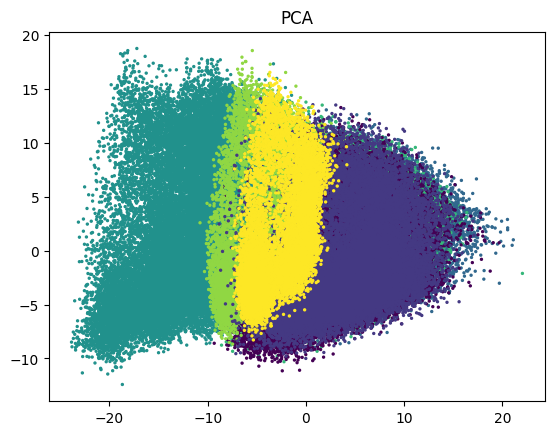

In [10]:
# compute PCA of data
from sklearn.decomposition import PCA
pcaer = PCA(n_components=200)
X_pca = pcaer.fit_transform(adata.X)
adata.obsm['X_pca'] = X_pca
adata.varm['pcs'] = pcaer.components_.T
plt.scatter(*X_pca[:, 0:2].T, c=np.unique(adata.obs['dpi'], return_inverse=True)[1], s=2)
plt.title('PCA')
plt.show()

In [11]:
import harmonypy as hm

pca_matrix = adata.obsm['X_pca']
print(pca_matrix.shape)

ho = hm.run_harmony(pca_matrix, adata.obs, 'Batch')
print(ho.Z_corr.shape)

adata.obsm['X_pca_harmony'] = ho.Z_corr

2026-03-04 12:05:08,158 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-03-04 12:05:08,158 - harmonypy - INFO -   Parameters:
2026-03-04 12:05:08,159 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-04 12:05:08,159 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-04 12:05:08,159 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-04 12:05:08,159 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-04 12:05:08,159 - harmonypy - INFO -     nclust: 100
2026-03-04 12:05:08,160 - harmonypy - INFO -     block_size: 0.05
2026-03-04 12:05:08,160 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-03-04 12:05:08,160 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-03-04 12:05:08,161 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-04 12:05:08,161 - harmonypy - INFO -     verbose: True
2026-03-04 12:05:08,161 - harmonypy - INFO -     random_state: 0
2026-03-04 12:05:08

(170444, 200)


2026-03-04 12:05:08,451 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 12:05:16,526 - harmonypy - INFO - KMeans initialization complete.
2026-03-04 12:05:16,658 - harmonypy - INFO - Iteration 1 of 10
2026-03-04 12:05:17,675 - harmonypy - INFO - Iteration 2 of 10
2026-03-04 12:05:18,675 - harmonypy - INFO - Converged after 2 iterations


(170444, 200)


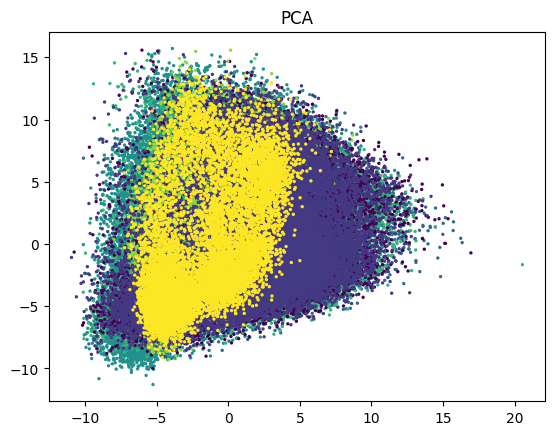

In [12]:
# Batch correct
plt.scatter(*adata.obsm['X_pca_harmony'][:, 0:2].T, c=np.unique(adata.obs['dpi'], return_inverse=True)[1], s=2)
plt.title('PCA')
plt.show()

Calculating PHATE...
  Running PHATE on 170444 observations and 200 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 3.95 seconds.
    Calculating KNN search...
    Calculated KNN search in 793.92 seconds.
    Calculating affinities...
    Calculated affinities in 432.44 seconds.
  Calculated graph and diffusion operator in 1230.88 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 31.01 seconds.
    Calculating KMeans...
    Calculated KMeans in 4.33 seconds.
  Calculated landmark operator in 38.52 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.36 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.93 seconds.
Calculated PHATE in 1272.71 seconds.


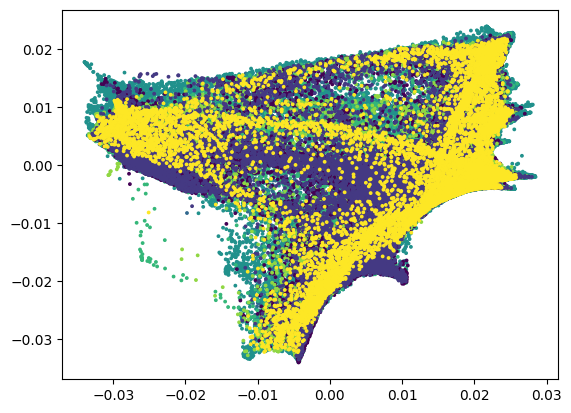

In [13]:
# run phate
import phate
phate_op = phate.PHATE(n_components=2, knn=7, t=30, n_jobs=-1)
X_phate = phate_op.fit_transform(adata.obsm['X_pca_harmony'])
plt.scatter(*X_phate.T, c=np.unique(adata.obs['dpi'], return_inverse=True)[1], s=3)
plt.show()

In [15]:
adata.obsm['X_phate_gene'] = X_phate
adata.write_h5ad('Axolotl_batch_corrected.h5ad')